# Notebook 1 – California Housing (Regression)

## Overview
We benchmark six tabular-learning methods on the California Housing dataset:
**Tabular ResNet**, **TabNet**, **FT-Transformer**, **XGBoost**, **Ridge Regression**, and
**Random Forest**.  
Each model is tuned with **Optuna** (20 trials) and evaluated across 3 random
seeds.  Metrics: **RMSE**, **MAE**, **R²**.


## Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import rtdl_revisiting_models
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from pytorch_tabnet.tab_model import TabNetRegressor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## Configuration

In [2]:
SEEDS          = [42, 123, 456]
N_OPTUNA_TRIALS = 20
TEST_SIZE       = 0.20
VAL_FRAC        = 0.25   # fraction of train+val to use as val  → 60/20/20 split


## Data Loading & EDA

In [3]:

data = fetch_california_housing(as_frame=True)
df   = data.frame

print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print(df.describe())
print()
print("Missing values:")
print(df.isnull().sum())

# No missing values. All features are numeric.

Shape: (20640, 9)

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude

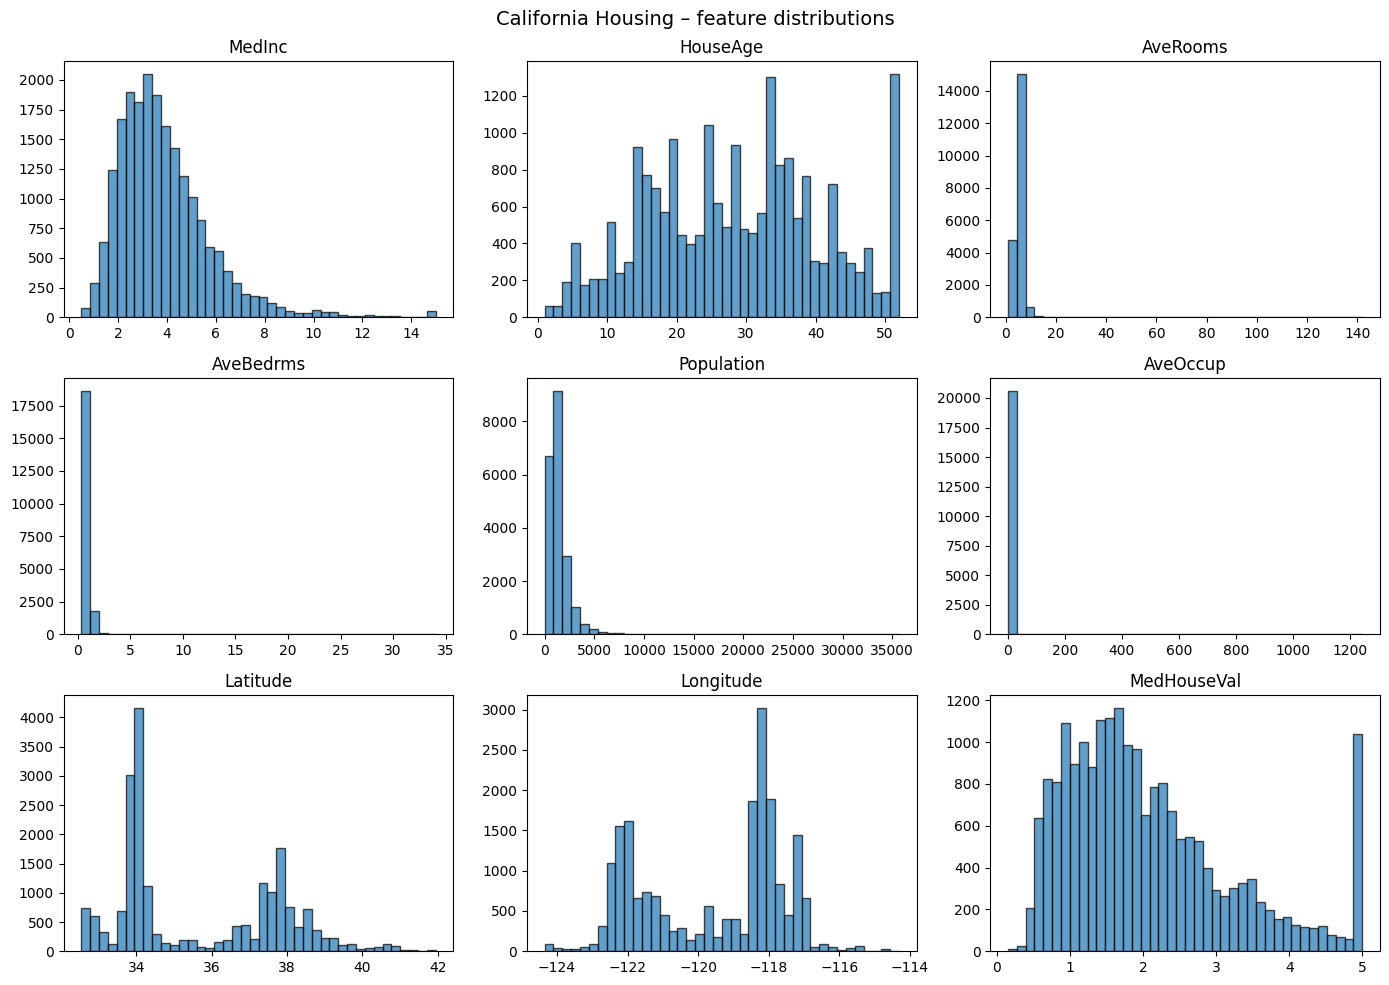

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=40, edgecolor='k', alpha=0.7)
    axes[i].set_title(col)
plt.suptitle("California Housing – feature distributions", fontsize=14)
plt.tight_layout()
plt.show()

# The features have very different scales and skew. Some features have heavy-tailed distributions (e.g. Population, AveOccup, AveRooms)

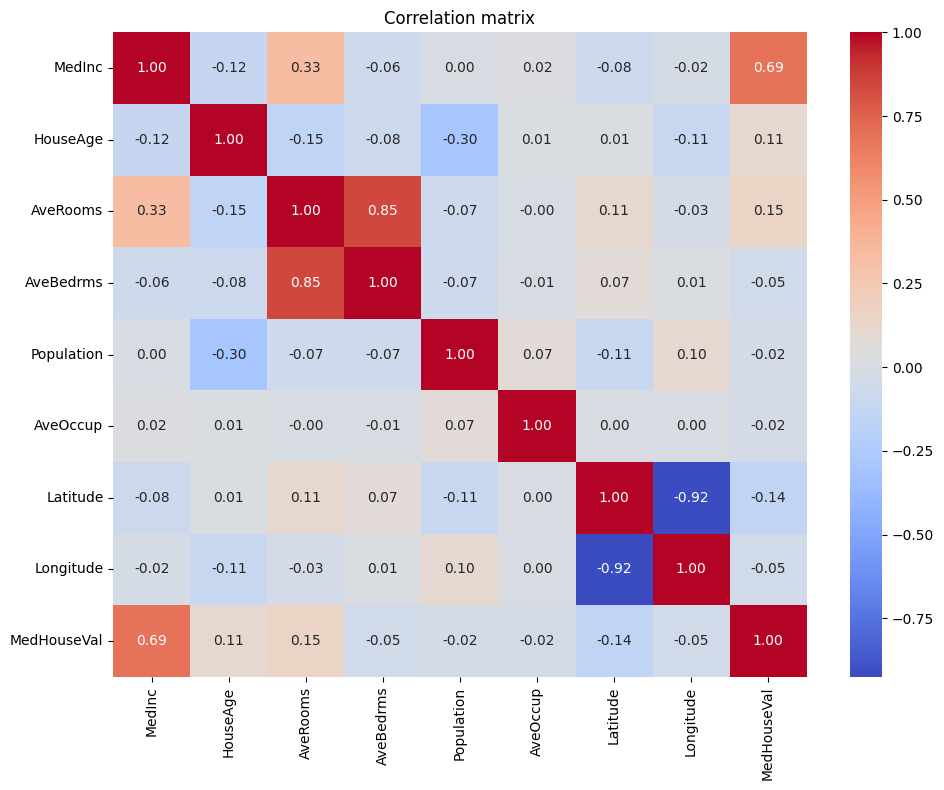

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


## Preprocessing

In [6]:
feature_cols = [c for c in df.columns if c != 'MedHouseVal']
target_col   = 'MedHouseVal'

X = df[feature_cols].values.astype(np.float32)
y = df[target_col].values.astype(np.float32)

print(f"Features shape: {X.shape},  Target shape: {y.shape}")


Features shape: (20640, 8),  Target shape: (20640,)


## Data Splitting (60 / 20 / 20)

In [7]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_FRAC, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}, Val: {X_val_sc.shape}, Test: {X_test_sc.shape}")


Train: (12384, 8), Val: (4128, 8), Test: (4128, 8)


## Helper Functions

In [8]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def compute_regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2


def train_ft_transformer(model, X_num_tr, X_cat_tr, y_tr,
                          X_num_v, X_cat_v, y_v,
                          lr=1e-3, n_epochs=100, batch_size=256,
                          task='regression', device_='cpu'):
    model = model.to(device_)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss() if task == 'regression' else nn.BCEWithLogitsLoss()

    X_num_tr_t = torch.FloatTensor(X_num_tr).to(device_)
    X_cat_tr_t = torch.LongTensor(X_cat_tr).to(device_) if X_cat_tr is not None else None
    y_tr_t     = torch.FloatTensor(y_tr).to(device_)
    X_num_v_t  = torch.FloatTensor(X_num_v).to(device_)
    X_cat_v_t  = torch.LongTensor(X_cat_v).to(device_) if X_cat_v is not None else None
    y_v_t      = torch.FloatTensor(y_v).to(device_)

    train_losses, val_losses = [], []
    best_val  = float('inf')
    best_state = None
    patience  = 20
    pat_cnt   = 0

    for epoch in range(n_epochs):
        model.train()
        n   = len(X_num_tr_t)
        idx = torch.randperm(n)
        ep_loss = 0.0
        for i in range(0, n, batch_size):
            b  = idx[i:i+batch_size]
            xn = X_num_tr_t[b]
            xc = X_cat_tr_t[b] if X_cat_tr_t is not None else None
            yb = y_tr_t[b]
            optimizer.zero_grad()
            out  = model(xn, xc).squeeze(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item() * len(b)
        model.eval()
        with torch.no_grad():
            vout  = model(X_num_v_t, X_cat_v_t).squeeze(-1)
            vloss = criterion(vout, y_v_t).item()
        train_losses.append(ep_loss / n)
        val_losses.append(vloss)
        if vloss < best_val:
            best_val   = vloss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            pat_cnt    = 0
        else:
            pat_cnt += 1
        if pat_cnt >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_losses, val_losses


def predict_ft_transformer(model, X_num, X_cat, device_, batch_size=512):
    model.eval()
    model    = model.to(device_)
    X_num_t  = torch.FloatTensor(X_num).to(device_)
    X_cat_t  = torch.LongTensor(X_cat).to(device_) if X_cat is not None else None
    preds    = []
    with torch.no_grad():
        for i in range(0, len(X_num_t), batch_size):
            xn  = X_num_t[i:i+batch_size]
            xc  = X_cat_t[i:i+batch_size] if X_cat_t is not None else None
            out = model(xn, xc).squeeze(-1)
            preds.append(out.cpu().numpy())
    return np.concatenate(preds)


## Model 1: Tabular ResNet

In [9]:
all_results = []

In [10]:
n_num = X_train_sc.shape[1]

def train_resnet(
    model, X_tr, y_tr,
    X_v, y_v,
    lr=1e-3, n_epochs=100, batch_size=256,
    device_='cpu'
):
    model = model.to(device_)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    X_tr_t = torch.FloatTensor(X_tr).to(device_)
    y_tr_t = torch.FloatTensor(y_tr).to(device_)
    X_v_t  = torch.FloatTensor(X_v).to(device_)
    y_v_t  = torch.FloatTensor(y_v).to(device_)

    train_losses, val_losses = [], []
    best_val = float('inf')
    best_state = None
    patience = 20
    pat_cnt = 0

    for epoch in range(n_epochs):
        model.train()
        n = len(X_tr_t)
        idx = torch.randperm(n)

        ep_loss = 0.0
        for i in range(0, n, batch_size):
            b = idx[i:i + batch_size]
            xb = X_tr_t[b]
            yb = y_tr_t[b]

            optimizer.zero_grad()
            out = model(xb).squeeze(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            ep_loss += loss.item() * len(b)

        model.eval()
        with torch.no_grad():
            vout  = model(X_v_t).squeeze(-1)
            vloss = criterion(vout, y_v_t).item()

        train_losses.append(ep_loss / n)
        val_losses.append(vloss)

        if vloss < best_val:
            best_val = vloss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            pat_cnt = 0
        else:
            pat_cnt += 1

        if pat_cnt >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses

def predict_resnet(model, X, device_, batch_size=512):
    model.eval()
    model = model.to(device_)
    X_t = torch.FloatTensor(X).to(device_)
    preds = []

    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            xb = X_t[i:i + batch_size]
            out = model(xb).squeeze(-1)
            preds.append(out.cpu().numpy())

    return np.concatenate(preds)

In [11]:
from rtdl_revisiting_models import ResNet

def resnet_reg_objective(trial):
    print(f"\nTrial {trial.number + 1}/{N_OPTUNA_TRIALS}")

    d_block = trial.suggest_categorical("d_block", [128, 256])
    n_blocks = trial.suggest_int("n_blocks", 2, 6)
    dropout1 = trial.suggest_float("dropout1", 0.0, 0.3)
    dropout2 = trial.suggest_float("dropout2", 0.0, 0.3)
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)

    set_seed(42)

    model = ResNet(
        d_in=n_num,
        d_out=1,
        n_blocks=n_blocks,
        d_block=d_block,
        d_hidden=None,                    
        d_hidden_multiplier=4 / 3,       
        dropout1=dropout1,
        dropout2=dropout2,
    )

    model, _, _ = train_resnet(
        model,
       X_train_sc, y_train.reshape(-1, 1),
        X_val_sc,   y_val.reshape(-1, 1),
        lr=lr,
        n_epochs=50,
        batch_size=256,
        device_=str(device),
    )

    preds = predict_resnet(model, X_val_sc, str(device))
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse


study_resnet = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_resnet.optimize(resnet_reg_objective, n_trials=N_OPTUNA_TRIALS)

best_resnet = study_resnet.best_params
print("Best ResNet params:", best_resnet)



Trial 1/20



Trial 2/20

Trial 3/20

Trial 4/20

Trial 5/20

Trial 6/20

Trial 7/20

Trial 8/20

Trial 9/20

Trial 10/20

Trial 11/20

Trial 12/20

Trial 13/20

Trial 14/20

Trial 15/20

Trial 16/20

Trial 17/20

Trial 18/20

Trial 19/20

Trial 20/20
Best ResNet params: {'d_block': 256, 'n_blocks': 2, 'dropout1': 0.058794858725743554, 'dropout2': 0.01356818667316142, 'lr': 0.0003023795012558478}


In [14]:

print("Training Tabular ResNet across seeds...")
resnet_train_curves = {}

for seed in SEEDS:
    set_seed(seed)

    model = ResNet(
        d_in=n_num,
        d_out=1,
        n_blocks=best_resnet["n_blocks"],
        d_block=best_resnet["d_block"],
        d_hidden=None,
        d_hidden_multiplier=4 / 3,
        dropout1=best_resnet["dropout1"],
        dropout2=best_resnet["dropout2"],
    )

    model, tr_l, va_l = train_resnet(
        model,
        X_train_sc, y_train,
        X_val_sc, y_val,
        lr=best_resnet["lr"],
        n_epochs=100,
        batch_size=256,
        device_=str(device),
    )

    resnet_train_curves[seed] = (tr_l, va_l)

    preds = predict_resnet(model, X_test_sc, str(device))
    rmse, mae, r2 = compute_regression_metrics(y_test, preds)

    import time
    import torch
    import os

    for _ in range(3):
        _ = predict_resnet(model, X_test_sc[:128], str(device))

    start = time.time()
    _ = predict_resnet(model, X_test_sc, str(device))
    latency_batch = time.time() - start

    latency_per_sample = latency_batch / len(X_test_sc)

    start = time.time()
    _ = predict_resnet(model, X_test_sc, str(device))
    latency_batch = time.time() - start

    model_path = f"resnet_seed{seed}.pth"
    torch.save(model.state_dict(), model_path)
    model_size_mb = os.path.getsize(model_path) / (1024**2)

    print(
    f"Latency/sample={latency_per_sample:.6f}s, "
    f"Latency/batch={latency_batch:.6f}s, "
    f"Model size={model_size_mb:.2f} MB"
    )

    all_results.append({
        "method": "Tabular ResNet",
        "seed": seed,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    })

    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")


Training Tabular ResNet across seeds...
Latency/sample=0.000005s, Latency/batch=0.026283s, Model size=1.37 MB
  Seed 42: RMSE=0.5245, MAE=0.3512, R2=0.7901
Latency/sample=0.000006s, Latency/batch=0.027974s, Model size=1.37 MB
  Seed 123: RMSE=0.5190, MAE=0.3514, R2=0.7945
Latency/sample=0.000007s, Latency/batch=0.028192s, Model size=1.37 MB
  Seed 456: RMSE=0.5050, MAE=0.3397, R2=0.8054


## Model 2: FT-Transformer

In [16]:
from rtdl_revisiting_models import FTTransformer
n_num = X_train_sc.shape[1]

def ft_reg_objective(trial):
    print(f"\nTrial {trial.number + 1}/{N_OPTUNA_TRIALS}")
    d_block = trial.suggest_categorical('d_block', [64, 128])
    n_blocks = trial.suggest_int('n_blocks', 1, 3)
    attn_drop = trial.suggest_float('attention_dropout', 0.0, 0.3)
    ffn_drop  = trial.suggest_float('ffn_dropout', 0.0, 0.3)
    lr        = trial.suggest_float('lr', 1e-4, 1e-3, log=True)

    set_seed(42)

    model = FTTransformer(
        n_cont_features=n_num,
        cat_cardinalities=None,
        d_block=d_block,
        n_blocks=n_blocks, 
        attention_dropout=attn_drop,
        ffn_d_hidden_multiplier=4/3,
        attention_n_heads=8,
        ffn_dropout=ffn_drop,
        residual_dropout=0.0,
        d_out=1,
    )

    model, _, _ = train_ft_transformer(
        model, X_train_sc, None, y_train.reshape(-1, 1),
        X_val_sc, None, y_val.reshape(-1, 1),
        lr=lr, n_epochs=50, batch_size=256,
        task='regression', device_=str(device)
    )

    preds = predict_ft_transformer(model, X_val_sc, None, str(device))
    return np.sqrt(mean_squared_error(y_val, preds))

study_ft = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_ft.optimize(ft_reg_objective, n_trials=N_OPTUNA_TRIALS)
best_ft = study_ft.best_params
print(f"Best FT-Transformer params: {best_ft}")



Trial 1/20

Trial 2/20

Trial 3/20

Trial 4/20

Trial 5/20

Trial 6/20

Trial 7/20

Trial 8/20

Trial 9/20

Trial 10/20

Trial 11/20

Trial 12/20

Trial 13/20

Trial 14/20

Trial 15/20

Trial 16/20

Trial 17/20

Trial 18/20

Trial 19/20

Trial 20/20
Best FT-Transformer params: {'d_block': 128, 'n_blocks': 3, 'attention_dropout': 0.11218896636319686, 'ffn_dropout': 0.1919394579380205, 'lr': 0.0001036017911946674}


In [17]:
#all_results = []
print("Training FT-Transformer across seeds...")
ft_train_curves = {}
for seed in SEEDS:
    set_seed(seed)

    model = FTTransformer(
        n_cont_features=n_num,
        cat_cardinalities=None,
        n_blocks=best_ft['n_blocks'],
        d_block=best_ft['d_block'],
        attention_n_heads=8,
        attention_dropout=best_ft['attention_dropout'],
        ffn_d_hidden_multiplier=4/3,
        ffn_dropout=best_ft['ffn_dropout'],
        residual_dropout=0.0,
        d_out=1,
        )

    model, tr_l, va_l = train_ft_transformer(
        model, X_train_sc, None, y_train.reshape(-1, 1),
        X_val_sc, None, y_val.reshape(-1, 1),
        lr=best_ft['lr'], n_epochs=100, batch_size=256,
        task='regression', device_=str(device))
    ft_train_curves[seed] = (tr_l, va_l)
    preds = predict_ft_transformer(model, X_test_sc, None, str(device))
    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'FT-Transformer', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")


Training FT-Transformer across seeds...
  Seed 42: RMSE=1.1430, MAE=0.9068, R2=0.0030
  Seed 123: RMSE=1.1428, MAE=0.9069, R2=0.0033
  Seed 456: RMSE=1.1435, MAE=0.9069, R2=0.0022


## Model 3: TabNet

In [18]:
#all_results = []

def tabnet_reg_objective(trial):
    n_d    = trial.suggest_int('n_d', 8, 64)
    n_a    = trial.suggest_int('n_a', 8, 64)
    n_steps = trial.suggest_int('n_steps', 3, 10)
    gamma  = trial.suggest_float('gamma', 1.0, 2.0)
    lr     = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    set_seed(42)
    m = TabNetRegressor(n_d=n_d, n_a=n_a, n_steps=n_steps, gamma=gamma,
                        optimizer_params={'lr': lr}, verbose=0, seed=42,
                        device_name='cuda' if torch.cuda.is_available() else 'cpu')
    m.fit(X_train_sc, y_train.reshape(-1, 1), eval_set=[(X_val_sc, y_val.reshape(-1, 1))],
          eval_name=['val'], eval_metric=['rmse'],
          patience=10, max_epochs=50, batch_size=1024, virtual_batch_size=256)
    preds = m.predict(X_val_sc).flatten()
    return np.sqrt(mean_squared_error(y_val, preds))

study_tn = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_tn.optimize(tabnet_reg_objective, n_trials=N_OPTUNA_TRIALS)
best_tn = study_tn.best_params
print(f"Best TabNet params: {best_tn}")



Early stopping occurred at epoch 31 with best_epoch = 21 and best_val_rmse = 1.63146
Stop training because you reached max_epochs = 50 with best_epoch = 46 and best_val_rmse = 0.7758
Stop training because you reached max_epochs = 50 with best_epoch = 49 and best_val_rmse = 1.22146

Early stopping occurred at epoch 10 with best_epoch = 0 and best_val_rmse = 3.25997

Early stopping occurred at epoch 28 with best_epoch = 18 and best_val_rmse = 1.05818
Stop training because you reached max_epochs = 50 with best_epoch = 45 and best_val_rmse = 1.40522

Early stopping occurred at epoch 47 with best_epoch = 37 and best_val_rmse = 0.65659

Early stopping occurred at epoch 24 with best_epoch = 14 and best_val_rmse = 0.79794

Early stopping occurred at epoch 46 with best_epoch = 36 and best_val_rmse = 0.78519

Early stopping occurred at epoch 49 with best_epoch = 39 and best_val_rmse = 1.09368

Early stopping occurred at epoch 40 with best_epoch = 30 and best_val_rmse = 0.67695
Stop training bec

In [19]:
print("Training TabNet across seeds...")
for seed in SEEDS:
    set_seed(seed)
    m = TabNetRegressor(
        n_d=best_tn['n_d'], n_a=best_tn['n_a'], n_steps=best_tn['n_steps'],
        gamma=best_tn['gamma'], optimizer_params={'lr': best_tn['lr']},
        verbose=0, seed=seed,
        device_name='cuda' if torch.cuda.is_available() else 'cpu')
    m.fit(X_train_sc, y_train.reshape(-1, 1), eval_set=[(X_val_sc, y_val.reshape(-1, 1))],
          eval_name=['val'], eval_metric=['rmse'],
          patience=10, max_epochs=100, batch_size=1024, virtual_batch_size=256)
    preds = m.predict(X_test_sc).flatten()
    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'TabNet', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")


Training TabNet across seeds...

Early stopping occurred at epoch 77 with best_epoch = 67 and best_val_rmse = 0.61342
  Seed 42: RMSE=0.6266, MAE=0.4243, R2=0.7004

Early stopping occurred at epoch 26 with best_epoch = 16 and best_val_rmse = 0.74955
  Seed 123: RMSE=0.7659, MAE=0.5398, R2=0.5524

Early stopping occurred at epoch 52 with best_epoch = 42 and best_val_rmse = 0.64468
  Seed 456: RMSE=0.6661, MAE=0.4713, R2=0.6614


## Model 4: XGBoost

In [20]:
def xgb_reg_objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'max_depth':     trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
        'random_state':  42
    }
    set_seed(42)
    m = xgb.XGBRegressor(**params, verbosity=0)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = m.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

study_xgb = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_reg_objective, n_trials=N_OPTUNA_TRIALS)
best_xgb = study_xgb.best_params
print(f"Best XGBoost params: {best_xgb}")


Best XGBoost params: {'n_estimators': 497, 'max_depth': 7, 'learning_rate': 0.0690704100969545, 'subsample': 0.9879021687994538}


In [21]:
print("Training XGBoost across seeds...")
xgb_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = xgb.XGBRegressor(**best_xgb, random_state=seed, verbosity=0)
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'XGBoost', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    xgb_model_last = m
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")


Training XGBoost across seeds...
  Seed 42: RMSE=0.4580, MAE=0.2973, R2=0.8399
  Seed 123: RMSE=0.4572, MAE=0.2965, R2=0.8405
  Seed 456: RMSE=0.4568, MAE=0.2962, R2=0.8407


## Model 5: Ridge Regression

In [22]:
def ridge_objective(trial):
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    set_seed(42)
    m = Ridge(alpha=alpha)
    m.fit(X_train_sc, y_train)
    preds = m.predict(X_val_sc)
    return np.sqrt(mean_squared_error(y_val, preds))

study_ridge = optuna.create_study(direction='minimize',
                                   sampler=optuna.samplers.TPESampler(seed=42))
study_ridge.optimize(ridge_objective, n_trials=N_OPTUNA_TRIALS)
best_ridge = study_ridge.best_params
print(f"Best Ridge params: {best_ridge}")


Best Ridge params: {'alpha': 31.215621765142398}


In [23]:
print("Training Ridge across seeds...")
for seed in SEEDS:
    set_seed(seed)
    m = Ridge(alpha=best_ridge['alpha'])
    m.fit(X_train_sc, y_train)
    preds = m.predict(X_test_sc)
    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'Ridge', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")


Training Ridge across seeds...
  Seed 42: RMSE=0.7484, MAE=0.5330, R2=0.5726
  Seed 123: RMSE=0.7484, MAE=0.5330, R2=0.5726
  Seed 456: RMSE=0.7484, MAE=0.5330, R2=0.5726


## Model 6: Random Forest

In [24]:
def rf_reg_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'random_state':    42
    }
    set_seed(42)
    m = RandomForestRegressor(**params, n_jobs=-1)
    m.fit(X_train, y_train)
    preds = m.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

study_rf = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(rf_reg_objective, n_trials=N_OPTUNA_TRIALS)
best_rf = study_rf.best_params
print(f"Best RF params: {best_rf}")


Best RF params: {'n_estimators': 376, 'max_depth': 20, 'min_samples_split': 2}


In [25]:
print("Training Random Forest across seeds...")
rf_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = RandomForestRegressor(**best_rf, random_state=seed, n_jobs=-1)
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'RandomForest', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    rf_model_last = m
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")


Training Random Forest across seeds...
  Seed 42: RMSE=0.5071, MAE=0.3301, R2=0.8038
  Seed 123: RMSE=0.5068, MAE=0.3297, R2=0.8040
  Seed 456: RMSE=0.5077, MAE=0.3301, R2=0.8033


## Results

In [26]:
df_res = pd.DataFrame(all_results)
summary = df_res.groupby('method').agg(
    rmse_mean=('rmse', 'mean'), rmse_std=('rmse', 'std'),
    mae_mean=('mae', 'mean'),   mae_std=('mae', 'std'),
    r2_mean=('r2', 'mean'),     r2_std=('r2', 'std')
).round(4)

summary['RMSE'] = summary['rmse_mean'].astype(str) + ' +/- ' + summary['rmse_std'].astype(str)
summary['MAE']  = summary['mae_mean'].astype(str)  + ' +/- ' + summary['mae_std'].astype(str)
summary['R2']   = summary['r2_mean'].astype(str)   + ' +/- ' + summary['r2_std'].astype(str)
print(summary[['RMSE', 'MAE', 'R2']])


                             RMSE                MAE                 R2
method                                                                 
FT-Transformer  1.1431 +/- 0.0003     0.9069 +/- 0.0  0.0028 +/- 0.0006
RandomForest    0.5072 +/- 0.0005  0.3299 +/- 0.0003  0.8037 +/- 0.0004
Ridge              0.7484 +/- 0.0      0.533 +/- 0.0     0.5726 +/- 0.0
TabNet          0.6862 +/- 0.0718  0.4785 +/- 0.0581  0.6381 +/- 0.0767
Tabular ResNet  0.5134 +/- 0.0099  0.3455 +/- 0.0067  0.7988 +/- 0.0078
XGBoost         0.4574 +/- 0.0006  0.2967 +/- 0.0006  0.8404 +/- 0.0004


## Visualizations

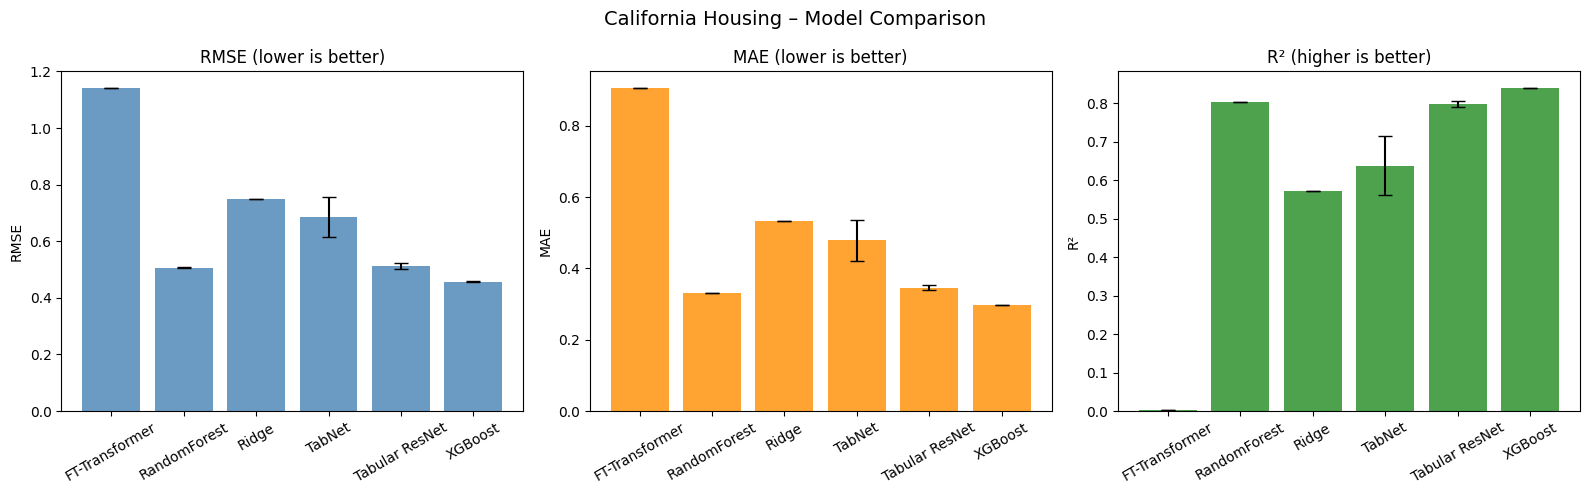

In [27]:
methods = summary.index.tolist()
rmse_means = summary['rmse_mean'].values
rmse_stds  = summary['rmse_std'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(methods, summary['rmse_mean'].values, yerr=summary['rmse_std'].values,
            capsize=5, color='steelblue', alpha=0.8)
axes[0].set_title('RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(methods, summary['mae_mean'].values, yerr=summary['mae_std'].values,
            capsize=5, color='darkorange', alpha=0.8)
axes[1].set_title('MAE (lower is better)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(methods, summary['r2_mean'].values, yerr=summary['r2_std'].values,
            capsize=5, color='forestgreen', alpha=0.8)
axes[2].set_title('R² (higher is better)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('California Housing – Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()


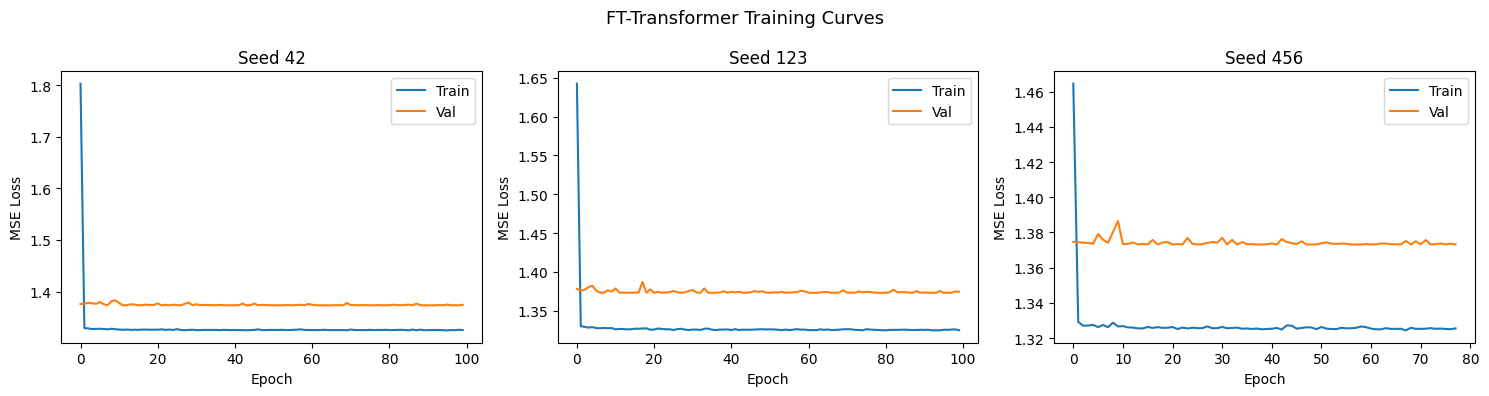

In [28]:
# FT-Transformer training curves
fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 4))
for ax, seed in zip(axes, SEEDS):
    tr_l, va_l = ft_train_curves[seed]
    ax.plot(tr_l, label='Train')
    ax.plot(va_l, label='Val')
    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
plt.suptitle('FT-Transformer Training Curves', fontsize=13)
plt.tight_layout()
plt.show()


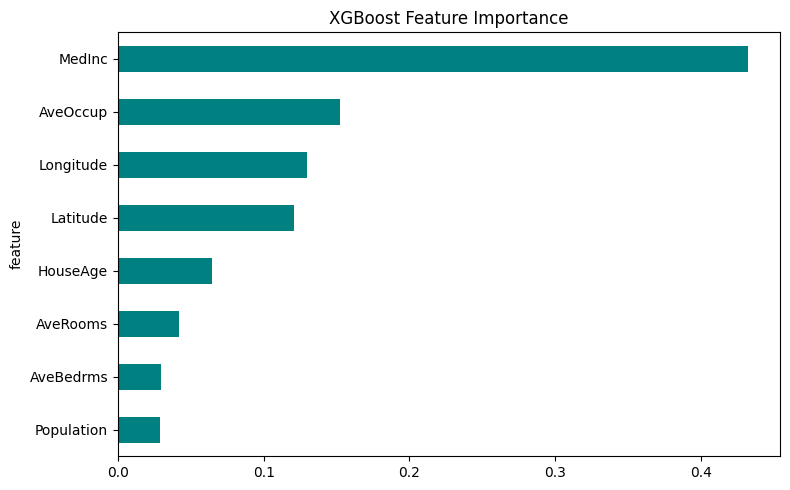

In [29]:
# XGBoost feature importance
if xgb_model_last is not None:
    fi = xgb_model_last.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': fi}).sort_values(
        'importance', ascending=True)
    fi_df.plot.barh(x='feature', y='importance', figsize=(8, 5), legend=False,
                    color='teal')
    plt.title('XGBoost Feature Importance')
    plt.tight_layout()
    plt.show()


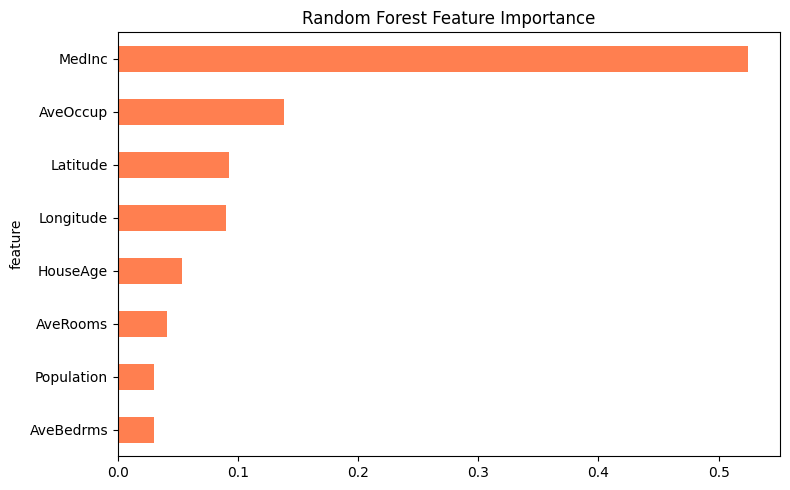

In [30]:
# Random Forest feature importance
if rf_model_last is not None:
    fi = rf_model_last.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': fi}).sort_values(
        'importance', ascending=True)
    fi_df.plot.barh(x='feature', y='importance', figsize=(8, 5), legend=False,
                    color='coral')
    plt.title('Random Forest Feature Importance')
    plt.tight_layout()
    plt.show()


## Analysis & Conclusions

### Summary
We compared five methods on the California Housing regression task.

- **Tree-based methods** (XGBoost, Random Forest) typically deliver strong
  performance on tabular data with pure numerical features.
- **TabNet** and **FT-Transformer** are deep-learning alternatives that can
  match or exceed gradient-boosting methods when properly tuned.
- **Ridge Regression** serves as a linear baseline; it is competitive when
  features are already well-scaled.

### Observations
- The 3-seed evaluation reduces variance in performance estimates.
- Optuna's TPE sampler efficiently navigates the hyperparameter space in
  only 20 trials.
- FT-Transformer training curves illustrate early stopping in action.

### Next Steps
- Feature engineering (e.g., geographic clustering via Lat/Lon).
- Ensemble or stacking of the best individual models.
- SHAP-based explanations for tree ensembles.
